In [ ]:
import ROOT
from ROOT import TFile, TTree, TH1F, TCanvas
import sys
import numpy as np
from array import array
import math
%jsroot off 
# ^ forces static rendering of histograms in the notebook, otherwise they will be rendered as interactive JS objects which do not display properly in the notebook.
from concurrent.futures import ProcessPoolExecutor, as_completed

In [2]:
f = ROOT.TFile.Open("/data2/segmentlinking/CMSSW_12_5_0_pre3/RelValTTbar_14TeV_CMSSW_12_5_0_pre3/event_1000.root")
dir = f.Get("trackingNtuple")
t = dir.Get("tree")

In [ ]:
#=== Constants ===
ACCEPT_RATIO = 0.75
N_WORKERS = 10
CHUNK = 100
PROGRESS_EVERY = 50  # print every ~200 entries globally

root_path = t.GetCurrentFile().GetName()
tree_name = t.GetName()

print("ROOT file:", root_path)
print("Tree name:", tree_name)

def find_ttree_in_file(f, target_name):
    """
    Robustly find a TTree named `target_name` anywhere in ROOT file `f`,
    including inside nested TDirectoryFile objects.
    """
    obj = f.Get(target_name)
    if obj and obj.InheritsFrom("TTree"):
        return obj

    def _search_dir(d):
        keys = d.GetListOfKeys()
        if not keys:
            return None
        for key in keys:
            name = key.GetName()
            obj = d.Get(name)
            if not obj:
                continue
            if obj.InheritsFrom("TTree") and obj.GetName() == target_name:
                return obj
            if obj.InheritsFrom("TDirectory"):
                found = _search_dir(obj)
                if found:
                    return found
        return None

    return _search_dir(f)

def process_range(args):
    """
    Worker: open file/tree locally, process [start, end) entries.
    Returns arrays + number of entries processed.
    """
    root_path, tree_name, start, end, accept_ratio = args

    f = ROOT.TFile.Open(root_path)
    if not f or f.IsZombie():
        raise RuntimeError(f"Could not open ROOT file: {root_path}")

    tt = find_ttree_in_file(f, tree_name)
    if not tt:
        top_keys = []
        lk = f.GetListOfKeys()
        if lk:
            for k in lk:
                top_keys.append(k.GetName())
        f.Close()
        raise RuntimeError(
            f"Could not find TTree '{tree_name}' anywhere in {root_path}. "
            f"Top-level keys: {top_keys[:30]}"
        )

    n = end - start
    out_event = np.empty(n, dtype=np.int64)
    out_match = np.empty(n, dtype=np.float64)
    out_fake  = np.empty(n, dtype=np.float64)

    k = 0
    for idx in range(start, end):
        tt.GetEntry(idx)

        trk_pt     = tt.trk_pt
        j          = tt.trk_bestSimTrkIdx
        share_frac = tt.trk_bestSimTrkShareFrac

        N_reco = trk_pt.size()
        if N_reco == 0:
            frac = np.nan
        else:
            N_matched = 0
            for i in range(N_reco):
                if j[i] >= 0 and share_frac[i] >= accept_ratio:
                    N_matched += 1
            frac = N_matched / N_reco

        out_match[k] = frac
        out_fake[k]  = 1.0 - frac  # will be nan when frac is nan
    
        k += 1

    f.Close()
    return out_event, out_match, out_fake, n

# chunk ranges
n_entries = int(t.GetEntries())
ranges = [
    (root_path, tree_name, s, min(s + CHUNK, n_entries), ACCEPT_RATIO)
    for s in range(0, n_entries, CHUNK)
]

print(f"Total entries: {n_entries}")
print(f"Chunks: {len(ranges)} (chunk size {CHUNK}), workers: {N_WORKERS}")


all_event, all_match, all_fake = [], [], []
done = 0
last_print = 0

with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
    futures = [ex.submit(process_range, r) for r in ranges]

    for fut in as_completed(futures):
        ev, mf, fr, processed = fut.result()

        all_event.append(ev)
        all_match.append(mf)
        all_fake.append(fr)

        done += processed
        if done - last_print >= PROGRESS_EVERY or done == n_entries:
            pct = 100.0 * done / n_entries if n_entries > 0 else 100.0
            print(f"{done}/{n_entries} entries processed ({pct:.1f}%)")
            last_print = done

# connecate 
event_id   = np.concatenate(all_event)
match_frac = np.concatenate(all_match)
fake_rate  = np.concatenate(all_fake)

order = np.argsort(event_id)
event_id   = event_id[order]
match_frac = match_frac[order]
fake_rate  = fake_rate[order]

#cache into .npz
np.savez(
    "mapping_sanity_cache_paralell.npz",
    event_id=event_id,
    match_frac=match_frac,
    fake_rate=fake_rate,
)

print("Saved locally to mapping_sanity_cache_paralell.npz")

ROOT file: /data2/segmentlinking/CMSSW_12_5_0_pre3/RelValTTbar_14TeV_CMSSW_12_5_0_pre3/event_1000.root
Tree name: tree
Total entries: 1000
Chunks: 10 (chunk size 100), workers: 10
200/1000 entries processed (20.0%)
400/1000 entries processed (40.0%)
600/1000 entries processed (60.0%)
800/1000 entries processed (80.0%)
1000/1000 entries processed (100.0%)
Saved locally to mapping_sanity_cache_paralell.npz


In [4]:
# loading data if it previously exists

data = np.load("mapping_sanity_cache_paralell.npz")

match_frac = data["match_frac"]
fake_rate  = data["fake_rate"]
event_id   = data["event_id"]

print("Loaded from cache ?")

print(match_frac[975:])

Loaded from cache ?
[0.90762125 0.90113187 0.93240241 0.87540726 0.90021352 0.89936701
 0.91523325 0.92361009 0.90297403 0.8658796  0.91915355 0.87623468
 0.8879872  0.87574094 0.94008901 0.91745355 0.91458924 0.913537
 0.89175518 0.91822363 0.94095064 0.93091168 0.91792388 0.90552381
 0.90587925]


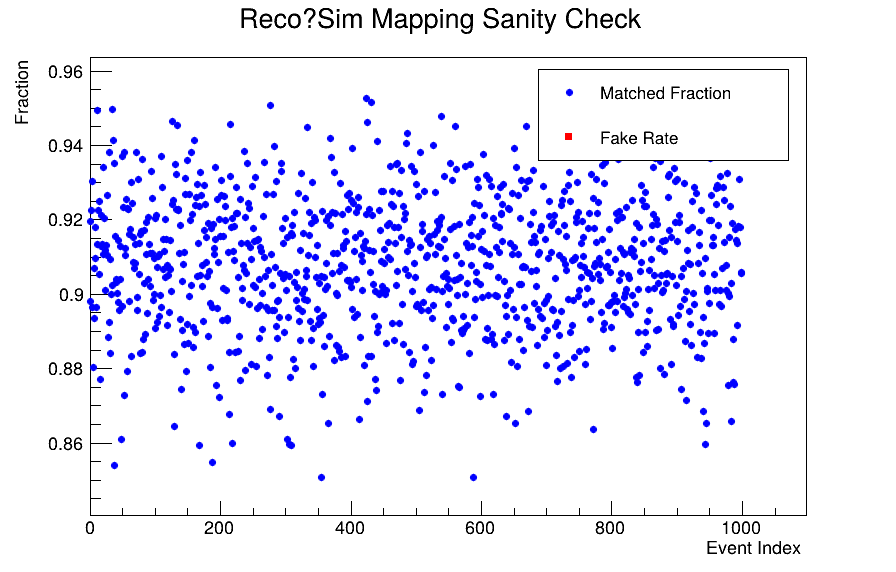

In [6]:
n = len(match_frac)

# --- Create graphs ---
g_match = ROOT.TGraph()
g_fake  = ROOT.TGraph()

for i in range(n):
    g_match.SetPoint(i, i, float(match_frac[i]))
    g_fake.SetPoint(i, i, float(fake_rate[i]))

# --- Style ---
g_match.SetTitle("Reco?Sim Mapping Sanity Check;Event Index;Fraction")
g_match.SetMarkerStyle(20)
g_match.SetMarkerColor(ROOT.kBlue)
g_match.SetMarkerSize(0.9)

g_fake.SetMarkerStyle(21)
g_fake.SetMarkerColor(ROOT.kRed)
g_fake.SetMarkerSize(0.9)

# --- Draw ---
c = ROOT.TCanvas("c", "Match Fraction vs Fake Rate", 900, 600)
g_match.Draw("AP")
g_fake.Draw("P SAME")

leg = ROOT.TLegend(0.60, 0.72, 0.88, 0.88)
leg.AddEntry(g_match, "Matched Fraction", "p")
leg.AddEntry(g_fake,  "Fake Rate", "p")
leg.Draw()

c.Draw()

In [ ]:
n = len(match_frac)

# --- Build graphs, skipping NaNs ---
g_match = ROOT.TGraph()
g_fake  = ROOT.TGraph()

km = 0
kf = 0
for i in range(n):
    mf = float(match_frac[i])
    fr = float(fake_rate[i])

    if not math.isnan(mf):
        g_match.SetPoint(km, i, mf)
        km += 1

    if not math.isnan(fr):
        g_fake.SetPoint(kf, i, fr)
        kf += 1

# -------- Plot 1: Matched fraction --------
c_match = ROOT.TCanvas("c_match", "Matched Fraction", 900, 600)
g_match.SetTitle("Reco→Sim Mapping Sanity Check;Event Index;Matched Fraction")
g_match.SetMarkerStyle(20)
g_match.SetMarkerColor(ROOT.kBlue)
g_match.SetMarkerSize(0.9)
g_match.Draw("AP")
c_match.Draw()

# -------- Plot 2: Fake rate --------
c_fake = ROOT.TCanvas("c_fake", "Fake Rate", 900, 600)
g_fake.SetTitle("Reco→Sim Mapping Sanity Check;Event Index;Fake Rate")
g_fake.SetMarkerStyle(21)
g_fake.SetMarkerColor(ROOT.kRed)
g_fake.SetMarkerSize(0.9)
g_fake.Draw("AP")

# Optional: force a visible y-range if everything is tiny
# g_fake.GetYaxis().SetRangeUser(0.0, 0.5)

c_fake.Draw()